In [33]:
import os
from pathlib import Path

import pandas as pd
import numpy as np
import tifffile

In [2]:
output_dir = Path('../data/spatial/regions/xenium')

In [3]:
basal = pd.read_parquet(output_dir / f'combined_counts_boundary.parquet',
                        columns=['KRT5', 'KRT14', 'KRT15', 'LAMB3', 'ACTA2'])

values = np.full((basal.shape[0],), np.nan, dtype=basal.values.dtype)
for c in basal.columns:
    mask = pd.isnull(values)
    values[mask] = basal[c][mask]



case_meta = pd.read_csv('/storage1/fs1/dinglab/Active/Projects/estorrs/3d-analysis/data/spatial/metadata/2d_data_tracking_metadata.csv')
to_tnbc = {x:y for x, y in case_meta[['sid', 'is_tnbc']].values}

basal['sid'] = ['_'.join(x.split('_')[:-1]) for x in basal.index.to_list()]
basal['is_tnbc'] = [to_tnbc[sid] for sid in basal['sid']]

values[basal['is_tnbc']] = basal[basal['is_tnbc']]['ACTA2']

basal['basal'] = values

basal

,KRT5,KRT14,KRT15,LAMB3,ACTA2,sid,is_tnbc,basal
region_id,,,,,,,,
SP003Z1-Fp1Us1_1_20,NaN,NaN,NaN,NaN,27268.0,SP003Z1-Fp1Us1_1,False,27268.0
SP003Z1-Fp1Us1_1_31,NaN,NaN,NaN,NaN,12.0,SP003Z1-Fp1Us1_1,False,12.0
SP003Z1-Fp1Us1_1_34,NaN,NaN,NaN,NaN,184.0,SP003Z1-Fp1Us1_1,False,184.0
SP003Z1-Fp1Us1_1_37,NaN,NaN,NaN,NaN,139.0,SP003Z1-Fp1Us1_1,False,139.0
SP003Z1-Fp1Us1_1_43,NaN,NaN,NaN,NaN,8.0,SP003Z1-Fp1Us1_1,False,8.0
...,...,...,...,...,...,...,...,...
SP050Z1-Fp1A1U2_3045,0.0,0.0,NaN,NaN,9.0,SP050Z1-Fp1A1U2,False,0.0
SP050Z1-Fp1A1U2_3050,0.0,0.0,NaN,NaN,2.0,SP050Z1-Fp1A1U2,False,0.0
SP050Z1-Fp1A1U2_3064,0.0,0.0,NaN,NaN,0.0,SP050Z1-Fp1A1U2,False,0.0


In [4]:
basal = basal[['sid', 'basal']]
basal

,sid,basal
region_id,,
SP003Z1-Fp1Us1_1_20,SP003Z1-Fp1Us1_1,27268.0
SP003Z1-Fp1Us1_1_31,SP003Z1-Fp1Us1_1,12.0
SP003Z1-Fp1Us1_1_34,SP003Z1-Fp1Us1_1,184.0
SP003Z1-Fp1Us1_1_37,SP003Z1-Fp1Us1_1,139.0
SP003Z1-Fp1Us1_1_43,SP003Z1-Fp1Us1_1,8.0
...,...,...
SP050Z1-Fp1A1U2_3045,SP050Z1-Fp1A1U2,0.0
SP050Z1-Fp1A1U2_3050,SP050Z1-Fp1A1U2,0.0
SP050Z1-Fp1A1U2_3064,SP050Z1-Fp1A1U2,0.0


In [5]:

def norm_per_sample(
    df: pd.DataFrame,
    sample_col: str = "sid",
    scale: float = 1e4,
) -> pd.DataFrame:
    """
    Pearson-correlate *target_gene* with every other gene inside each sample.

    Normalisation pipeline (per sample)
    -----------------------------------
    1. **Sample/library normalisation**
           cp10k = counts / Σ_all_regions&genes(counts) * 10 000
    2. **Row (region) normalisation**
           row_norm = cp10k / row_sum(cp10k)

       • Rows with a 0 or NaN sum stay NaN.
       • A gene that is entirely NaN within a sample yields NaN correlation.

    Returns
    -------
    DataFrame  (index = sample IDs, columns = genes ≠ *target_gene*)
    """

    gene_cols = df.columns.drop(sample_col)
    exprs = []

    for sid, g in df.groupby(sample_col, sort=False):
        arr = g[gene_cols].to_numpy(dtype=float, copy=False)

        # ---------- 1. sample-level normalisation -------------------------
        total = np.nansum(arr)
        if total == 0 or np.isnan(total):
            # no usable data in this sample
            results.append(
                pd.Series(np.nan, index=gene_cols.drop(target_gene), name=sid)
            )
            continue

        arr *= scale / total          # in-place counts-per-10 k

        # ---------- 2. row (region) normalisation ------------------------
        row_sum = np.nansum(arr, axis=1, keepdims=True)
        with np.errstate(divide="ignore", invalid="ignore"):
            arr = np.divide(
                arr,
                row_sum,
                out=np.full_like(arr, np.nan),
                where=row_sum != 0,
            )

        # ---------- 3. correlation --------------------------------------
        expr = pd.DataFrame(arr, columns=gene_cols, index=g.index)
        exprs.append(expr)
#         corr = expr.corrwith(expr[target_gene], axis=0, method="pearson")
#         corr = corr.drop(target_gene)          # exclude self-correlation
#         results.append(corr.rename(sid))

    return exprs


In [6]:
df = pd.read_parquet(output_dir / f'combined_counts_boundary.parquet')
df.insert(0, 'sid', ['_'.join(x.split('_')[:-1]) for x in df.index.to_list()])
df['basal_target'] = basal['basal']
exprs = norm_per_sample(df)
exprs[0]

,ABCC11,ACE2,ACKR1,ACTA2,ACTG2,ADAM28,ADAMTS1,ADGRE1,ADGRL4,ADH1C,...,RHOD,ROBO1,SCGB1A1,SCGB3A1,SETD7,TGFBI,TIMP1,TXNIP,pks+.Escherichia.coli.clbB,basal_target
region_id,,,,,,,,,,,,,,,,,,,,,
SP003Z1-Fp1Us1_1_20,0.000114,0.000227,0.000334,0.007862,0.015402,0.000857,0.013564,0.000249,0.002216,0.000535,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.007862
SP003Z1-Fp1Us1_1_31,0.000000,0.000000,0.000414,0.004967,0.012417,0.000000,0.031043,0.000414,0.000414,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.004967
SP003Z1-Fp1Us1_1_34,0.000000,0.000095,0.000000,0.017532,0.037256,0.000476,0.034778,0.000095,0.000953,0.000191,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.017532
SP003Z1-Fp1Us1_1_37,0.000109,0.000219,0.000000,0.015198,0.031271,0.000328,0.035863,0.000109,0.001749,0.000109,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.015198
SP003Z1-Fp1Us1_1_43,0.000000,0.000000,0.000000,0.003515,0.011424,0.000000,0.020650,0.000000,0.000000,0.000879,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.003515
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SP003Z1-Fp1Us1_1_17524,0.001695,0.000000,0.000000,0.004520,0.015819,0.000000,0.005650,0.000000,0.000565,0.002260,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.004520
SP003Z1-Fp1Us1_1_17530,0.001147,0.000000,0.000000,0.006881,0.009174,0.001147,0.001147,0.000000,0.009174,0.001147,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.006881
SP003Z1-Fp1Us1_1_17533,0.001106,0.001106,0.001106,0.001106,0.004425,0.000000,0.000000,0.001106,0.003319,0.001106,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001106


In [14]:
stacks = []
for expr in exprs:
    stacks.append(expr[['basal_target']])
stacked = pd.concat(stacks, axis=0)
stacked

,basal_target
region_id,
SP003Z1-Fp1Us1_1_20,0.007862
SP003Z1-Fp1Us1_1_31,0.004967
SP003Z1-Fp1Us1_1_34,0.017532
SP003Z1-Fp1Us1_1_37,0.015198
SP003Z1-Fp1Us1_1_43,0.003515
...,...
SP050Z1-Fp1A1U2_3045,0.000000
SP050Z1-Fp1A1U2_3050,0.000000
SP050Z1-Fp1A1U2_3064,0.000000


In [15]:
stacked['sid'] = ['_'.join(x.split('_')[:-1]) for x in stacked.index.to_list()]
stacked['case'] = [x.split('-')[0] for x in stacked['sid']]
stacked['label'] = [x.split('_')[-1] for x in stacked.index.to_list()]
stacked.columns = ['score', 'sid', 'case', 'label']
stacked

,score,sid,case,label
region_id,,,,
SP003Z1-Fp1Us1_1_20,0.007862,SP003Z1-Fp1Us1_1,SP003Z1,20
SP003Z1-Fp1Us1_1_31,0.004967,SP003Z1-Fp1Us1_1,SP003Z1,31
SP003Z1-Fp1Us1_1_34,0.017532,SP003Z1-Fp1Us1_1,SP003Z1,34
SP003Z1-Fp1Us1_1_37,0.015198,SP003Z1-Fp1Us1_1,SP003Z1,37
SP003Z1-Fp1Us1_1_43,0.003515,SP003Z1-Fp1Us1_1,SP003Z1,43
...,...,...,...,...
SP050Z1-Fp1A1U2_3045,0.000000,SP050Z1-Fp1A1U2,SP050Z1,3045
SP050Z1-Fp1A1U2_3050,0.000000,SP050Z1-Fp1A1U2,SP050Z1,3050
SP050Z1-Fp1A1U2_3064,0.000000,SP050Z1-Fp1A1U2,SP050Z1,3064


In [17]:
f = stacked[stacked['case']=='HT704B1']
f

,score,sid,case,label
region_id,,,,
HT704B1-S1H3Fp1U1_1,0.005402,HT704B1-S1H3Fp1U1,HT704B1,1
HT704B1-S1H3Fp1U1_2,0.004488,HT704B1-S1H3Fp1U1,HT704B1,2
HT704B1-S1H3Fp1U1_4,0.019564,HT704B1-S1H3Fp1U1,HT704B1,4
HT704B1-S1H3Fp1U1_11,0.004960,HT704B1-S1H3Fp1U1,HT704B1,11
HT704B1-S1H3Fp1U1_12,0.029069,HT704B1-S1H3Fp1U1,HT704B1,12
...,...,...,...,...
HT704B1-S1H3Fp1U50_4143,0.000000,HT704B1-S1H3Fp1U50,HT704B1,4143
HT704B1-S1H3Fp1U50_4148,0.000079,HT704B1-S1H3Fp1U50,HT704B1,4148
HT704B1-S1H3Fp1U50_4149,0.000711,HT704B1-S1H3Fp1U50,HT704B1,4149


In [34]:
f = stacked[stacked['case']=='HT891Z1']
f

,score,sid,case,label
region_id,,,,
HT891Z1-S2H3Fp1U1_3,0.001754,HT891Z1-S2H3Fp1U1,HT891Z1,3
HT891Z1-S2H3Fp1U1_6,0.005162,HT891Z1-S2H3Fp1U1,HT891Z1,6
HT891Z1-S2H3Fp1U1_9,0.009151,HT891Z1-S2H3Fp1U1,HT891Z1,9
HT891Z1-S2H3Fp1U1_12,0.004552,HT891Z1-S2H3Fp1U1,HT891Z1,12
HT891Z1-S2H3Fp1U1_14,0.009450,HT891Z1-S2H3Fp1U1,HT891Z1,14
...,...,...,...,...
HT891Z1-S2H3Fp1U94_3080,0.000428,HT891Z1-S2H3Fp1U94,HT891Z1,3080
HT891Z1-S2H3Fp1U94_3091,0.001390,HT891Z1-S2H3Fp1U94,HT891Z1,3091
HT891Z1-S2H3Fp1U94_3100,0.000000,HT891Z1-S2H3Fp1U94,HT891Z1,3100


In [35]:
for sid in set(f['sid']):
    fp = output_dir / f'{sid}_epi_region_labeled.npy'
    assert fp.is_file()
    print(f'scp estorrs@compute1-client-1.ris.wustl.edu:{fp.absolute()} ./')
#     print(str(fp.absolute()))

scp estorrs@compute1-client-1.ris.wustl.edu:/storage1/fs1/dinglab/Active/Projects/estorrs/3d-analysis/notebooks/../data/spatial/regions/xenium/HT891Z1-S2H3Fp1U69_epi_region_labeled.npy ./
scp estorrs@compute1-client-1.ris.wustl.edu:/storage1/fs1/dinglab/Active/Projects/estorrs/3d-analysis/notebooks/../data/spatial/regions/xenium/HT891Z1-S2H3Fp1U32_epi_region_labeled.npy ./
scp estorrs@compute1-client-1.ris.wustl.edu:/storage1/fs1/dinglab/Active/Projects/estorrs/3d-analysis/notebooks/../data/spatial/regions/xenium/HT891Z1-S2H3Fp1U104_epi_region_labeled.npy ./
scp estorrs@compute1-client-1.ris.wustl.edu:/storage1/fs1/dinglab/Active/Projects/estorrs/3d-analysis/notebooks/../data/spatial/regions/xenium/HT891Z1-S2H3Fp1U94_epi_region_labeled.npy ./
scp estorrs@compute1-client-1.ris.wustl.edu:/storage1/fs1/dinglab/Active/Projects/estorrs/3d-analysis/notebooks/../data/spatial/regions/xenium/HT891Z1-S2H3Fp1U59_epi_region_labeled.npy ./
scp estorrs@compute1-client-1.ris.wustl.edu:/storage1/fs1/d

In [36]:
f.to_csv(output_dir / 'HT891Z1_region_values.txt', sep='\t')

In [20]:
labeled = np.load('/storage1/fs1/dinglab/Active/Projects/estorrs/3d-analysis/notebooks/../data/spatial/regions/xenium/HT704B1-S1H3Fp1U17_epi_region_labeled.npy')
labeled.shape

(725, 846)

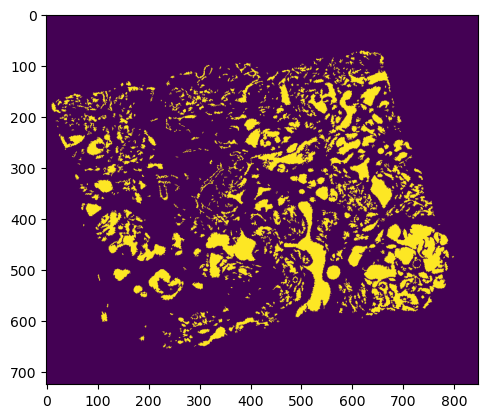

In [22]:
import matplotlib.pyplot as plt
plt.imshow(labeled > 0)

In [23]:
f[f['sid']=='HT704B1-S1H3Fp1U17']

,score,sid,case,label
region_id,,,,
HT704B1-S1H3Fp1U17_10,0.004740,HT704B1-S1H3Fp1U17,HT704B1,10
HT704B1-S1H3Fp1U17_14,0.000521,HT704B1-S1H3Fp1U17,HT704B1,14
HT704B1-S1H3Fp1U17_16,0.010926,HT704B1-S1H3Fp1U17,HT704B1,16
HT704B1-S1H3Fp1U17_17,0.011374,HT704B1-S1H3Fp1U17,HT704B1,17
HT704B1-S1H3Fp1U17_21,0.008989,HT704B1-S1H3Fp1U17,HT704B1,21
...,...,...,...,...
HT704B1-S1H3Fp1U17_4306,0.000112,HT704B1-S1H3Fp1U17,HT704B1,4306
HT704B1-S1H3Fp1U17_4308,0.000000,HT704B1-S1H3Fp1U17,HT704B1,4308
HT704B1-S1H3Fp1U17_4321,0.000000,HT704B1-S1H3Fp1U17,HT704B1,4321


In [26]:
np.count_nonzero(labeled == 4337)

0

In [30]:
!ls -l /storage1/fs1/dinglab/Active/Projects/estorrs/3d-analysis/notebooks/../data/spatial/regions/xenium/HT704B1-S1H3Fp1U17_epi_region_labeled.npy

-rw-------. 1 estorrs domain users 2453528 Jun 18 17:14 /storage1/fs1/dinglab/Active/Projects/estorrs/3d-analysis/notebooks/../data/spatial/regions/xenium/HT704B1-S1H3Fp1U17_epi_region_labeled.npy
